<a href="https://colab.research.google.com/github/dom-dang/7.C01/blob/main/7C01_PSET5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  <center> Problem Set 5 (FASTA) <center>
<center> Spring 2026 <center>
<center> 7.C01/7.C51, 20.C01/20.C51 <center>
<center> Due: Monday, May 4, 2026 at 3:00 PM ET. <center>

<b>Name:</b> Dominique Dang

<b>Kerberos ID:</b> ddang

## Learning Objective
In this problem set, you will learn to represent protein sequences in FASTA format and implement a variational auto-encoder (VAE) to encode these sequences into a continuous latent space. You will also use transformers with and without positional encodings to predict DNA binding sites, demonstrating the importance of positional information in sequential biological data.

## Instructions
- This problem set has two modeling tasks with several sub-questions. Some are marked grad version, which are required for graduate students (X.C51) but optional for others. Points for all students are in <font color="blue">blue</font>, while grad-only points are in <font color="orange">orange</font>. There is one problem that is undergrad only in <font color="purple">purple</font>. The total points are 75 for undergraduates and 100 for graduates.

- To get started, make your own copy of this notebook template in Colab (e.g., "Save a copy in Drive") before editing.

    - Important: this problem set requires a GPU. In Google Colab go to `Edit -> Notebook settings` and set the `Hardware accelerator` to a GPU before running the notebook (changing the runtime resets the notebook). See the GPU section below for additional help.

- Collaboration is encouraged and AI tools are permitted, but submitting work that is not your own is plagiarism. Any collaboration or assistance from others or from an LLM (including utilities integrated in Colab) must be described at the end of your submission.

- Additional notes about how to use this template:
    - Put your code in the code blocks flagged with `############# Code ##########`.

    -  Numerical answers yielded from running the code should be included in an Answer Block (see next cell).

    - We have provided print statements where numerical answers are expected.

    -  Your answer should be contained in a variable which you defined either in the Answer Block or the Code Block.

    - When a qualitative answer is expected, place those comments as Markdown/Text cells; when asked for within Code blocks, you can write answer as code comments by placing a # before your answer.

- Submission: upload your completed `pset5.ipynb` to Gradescope. Ensure the notebook runs without error and includes all necessary code, plots, and outputs. Comments are encouraged; place conceptual answers in Markdown/Text cells.

## Background (optional)

### FASTA for representing proteins

<div align="center">
  <img src="https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps5-bio/figures/protein_primary.png" width="600px" />
</div>
<div align="center">A protein (left; <a href="https://www.rcsb.org/structure/7KSC">source</a>) is a sequence of amino acids (center; <a href="https://en.m.wikipedia.org/wiki/File:Protein_primary_structure.svg">source</a>) that can be represented as a sequence of letters in the FASTA format (right).</div>

We've discussed how the structures of molecules are commonly represented with SMILES strings. What about nucleotide (DNA, RNA) sequences or amino acid (protein) sequences? We, of course, could also represent them with SMILES strings but these would get very long! Fortunately, diversity in nucleotides can largely be captured by sequences of adenosine (A), cytosine (C), guanine (G), thymine (T), or uracil (U). Diversity in most proteins can similarly be captured by sequences of 20 amino acids. Thus, as you likely can imagine after considering SMILES, the bioinformatics community has developed the FASTA format for the representation of nucleic acids and proteins. Like SMILES, the FASTA format is a text-based notation describing structure using short ASCII strings. In the FASTA format, one letter represents one amino acid or one nucleotide. In this pset, we will use the FASTA format for proteins. A table to translate each one-letter abbreviation to the full amino acid name can be viewed <a href="https://en.wikipedia.org/wiki/FASTA_format#Sequence_representation">here</a>.

## Instructions

Put your code in the code blocks flagged with `########## Code ##########`.

Numerical answers yielded from running the code should be included in an Answer Block (see next cell).

We have provided print statements where numerical answers are expected.

Your answer should be contained in a variable which you defined either in the Answer Block or the Code Block.

When a qualitative answer is expected, place those comments as Markdown/Text cells; when asked for within Code blocks, you can write answer as code comments by placing a # before your answer.

Your Answer Block should look like the following:

In [2]:
########## Answer ##########

ans = 2
print("My answer is: {}.".format(ans))

# My regressor over-fitted the training data, I need to add regularization

########## Answer ##########

My answer is: 2.


## Imports

In [7]:
import os
import glob
import math
import random as r
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.optim as optim
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset

from tqdm import tqdm
from scipy.stats import norm
from sklearn import preprocessing
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

## Grading guideline

- Didn't answer the question 0%
- Showed some attempts, but clearly didn't try enough: 25%
- Showed solid attempts (showed code) but does not answer the question directly: 50%
- Showed solid attempts and get the question wrong: 60-80%
- Showed solid attempts with some small mistakes: 80-90%
- Showed code and answered the questions correctly: 100%

## Download required data

In [3]:
!wget https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps5-bio/data/luxA_train.csv
!wget https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps5-bio/data/luxA_val.csv
!wget https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps5-bio/data/luxA_test.csv
!wget https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps2-bio/data/dna_binding.csv

--2026-04-26 23:11:08--  https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps5-bio/data/luxA_train.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4422080 (4.2M) [text/plain]
Saving to: ‘luxA_train.csv’

luxA_train.csv      100%[===================>]   4.22M  --.-KB/s    in 0.03s   

2026-04-26 23:11:09 (140 MB/s) - ‘luxA_train.csv’ saved [4422080/4422080]

--2026-04-26 23:11:09--  https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps5-bio/data/luxA_val.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK

## Part 1: Variational auto-encoders (VAEs) for protein sequences

Variational auto-encoders (VAEs) are a class of generative models. Adapted from the VAE architecture for SMILES detailed in <a href="#gomez2018automatic">Gómez-Bombarelli et al. (2018)</a>, this problem implements a VAE for protein sequences represented in FASTA format. The encoder consists of gated recurrent units (GRUs) to encode a FASTA sequence into a latent representation. The decoder is also a stacked GRU that takes the latent representation to reconstruct the input FASTA. The autoencoder is trained to use the encoder and decoder to reconstruct your input as closely as possible. In this exercise, you will be asked to implement the sampling and loss function for a FASTA-VAE. The dataset used for this exercise is from <a href="#hawkinshooker2018vaeprotein">Hawkins-Hooker et al. (2021)</a>. We provide a dataset of 17,403 protein sequence homologues of the *luxA* bacterial luciferase protein. This protein makes bacteria light up (i.e., bioluminesce); thus, the application of generative ML here could enable us to discover and formulate novel luminescence proteins.

<div align="center">
  <img src="https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps5-bio/figures/vae_fasta.png" width="600px" />
</div>
<div align="center">Applying a VAE on FASTA sequences for protein design, adapted from <a href="#gomez2018automatic">Gómez-Bombarelli et al. (2018)</a> which developed a SMILES VAE for molecular design.</div>

You'll notice that we provided the code chunk to load in the train (70%), validation (10%), and test (20%) data. Rather than implementing random splitting, to avoid highly similar sequences appearing in the train and validation sets (and hence avoid overfitting), the data was split by first clustering all sequences using MMseq2 and adding discrete clusters to each split. We have provided the split train/validation/test data for you (`luxA_train`, `luxA_val`, `luxA_test`), so you should simply run the code chunks to load the data. Each of these `pandas` dataframes has one column containing the amino acid sequences (`aa_sequence`). We also provide a list of string characters in `aa_charset` which you can use as a dictionary for FASTA.

**Note:** The sequences were aligned via multiple sequence alignment (MSA). All columns of the MSA that were unoccupied in the target *luxA* protein were not considered (marked with "-" in the FASTA representation). All sequences were padded to have equivalent length (360 amino acid positions).

In [4]:
########## Run ##########

luxA_train = pd.read_csv("luxA_train.csv")
luxA_val = pd.read_csv("luxA_val.csv")
luxA_test = pd.read_csv("luxA_test.csv")

########## Run ##########

In [5]:
########## Run ##########

# character list for FASTA protein sequences
aa_charset = ['-', 'A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K',
              'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']

# define encoder
enc = preprocessing.LabelEncoder().fit(aa_charset)

# determine max length of FASTA protein sequences (already padded to have same length)
max_len = len(luxA_train.aa_sequence[0]) # 360

########## Run ##########

### 1.1 <font color="blue">(5 points)</font> Encode protein sequences into numerical vectors

**Task:** Encode each character in a FASTA sequence into categorical numbers (note that this is *not* the same as one-hot encoding) using <a href="https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html">`LabelEncoder()`</a>. Transform your *encoded* train, validation, and test FASTA data into `torch.LongTensor` objects. This is an unsupervised learning task, so there are no labels. Next, like what you did in prior assignments, use a `DataLoader` with `batch=256` and `shuffle=True`.

In [8]:
########## Code ##########

X_train = torch.LongTensor(np.array([enc.transform(list(seq)) for seq in luxA_train.aa_sequence]))
X_val = torch.LongTensor(np.array([enc.transform(list(seq)) for seq in luxA_val.aa_sequence]))
X_test = torch.LongTensor(np.array([enc.transform(list(seq)) for seq in luxA_test.aa_sequence]))

batch_size = 256

train_data = TensorDataset(X_train)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

val_data = TensorDataset(X_val)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=True)

test_data = TensorDataset(X_test)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

########## Code ##########

### 1.2 <font color="blue">(15 points)</font> Implement the reparametrization trick

We have provided the implementation for a FASTA-VAE with the `VAE()` class. In VAEs, the encoding of an input $x$ into an embedding $z$ is not deterministic. The model is trying to compress the data into a latent distribution via a conditional distribution $Q_{\phi}(z|x) = \mathcal{N} (\mu_{\phi} , \sigma_{\phi} ^2 )$ which is parametrized by an encoder function, $\phi$. The model needs to sample from the distribution: $z \sim Q_{\phi}(z|x)$. However, this sampling process requires some extra attention because we want to ensure the sampling procedure is differentiable for gradient optimization. Generally, we cannot do this for a sampling process
$$ z \sim \mathcal{N}(\mu_{\phi} , \sigma_{\phi}^2) $$
since the derivatives $\frac{dz}{d \mu_{\phi}}$ and $\frac{dz}{d \sigma_{\phi}}$ are not clearly defined for this sampling procedure. However, we can use the reparameterization trick which suggests that we randomly sample $\epsilon$ from a unit multivariate Gaussian, and then shift the randomly sampled $\epsilon$ by the latent distribution's mean $\mu$ and scale it by $\sigma$.
$$ \epsilon \sim \mathcal{N}(0, 1) $$
$$ z = \mu_{\phi}+  \epsilon \cdot \sigma_{\phi} $$

The reparameterization trick makes the sampling process from a multivariate Gaussian differentiable! The reason why it works is because the randomness in the sampling is 'reparameterized' into a leaf node which does not require gradient calculation in the backward computation. To put it more concretely, during the backpropagation process when the gradient $\frac{dL}{dz}$ is computed ($L$ is the scalar loss function), the gradients on $\mu_{\phi}$ and $\sigma_{\phi}$ can be further computed with the following.
$$ \frac{dL}{d\mu_{\phi}} = \frac{dL}{dz} \frac{dz}{d\mu_{\phi}} = \frac{dL}{dz} $$
$$ \frac{dL}{d\sigma_{\phi}} = \frac{dL}{dz} \frac{dz}{d\sigma_{\phi}} = \frac{dL}{dz} \epsilon $$

The distributional output of the encoder input requires additional attention. Note that the encoder module parametrized by an MLP might output a negative $\sigma_{\phi}^2$ which might annoy a statistician. The numerical trick to ensure that $\sigma_{\phi}$ has only positive values is to output the $\log$ of $\sigma_{\phi}^2$ instead and then exponentiate:
$$ \mu_{\phi}, \log \sigma_{\phi}^2 = \texttt{encoder(FASTA)} $$
$$ \sigma_{\phi} = \exp\left(\frac{1}{2} \log \sigma_{\phi}^2\right) $$

**Task:** Implement the function to transform $\log\sigma_{\phi}^2$ to $\sigma_{\phi}$ in `VAE.get_std()`. Then, implement the reparametrization trick in `VAE.reparametrize()` which takes two inputs: $\mu_{\phi}$ and $\sigma_{\phi}$ and outputs a latent vector $z$. You will need the `torch.randn` method to sample $\varepsilon$. Test your code using `VAE.reparametrize()` to generate 1000 samples from a 1D distribution with $\mu=0$ and $\sigma^2 = 1$ and compare the sampled distribution with $\mathcal{N}(0,1)$.

In [9]:
class VAE(nn.Module):
    def __init__(self, rnn_enc_hid_dim, enc_nconv, encoder_hid, z_dim,
                 rnn_dec_hid_dim, dec_nconv, aa_seq_len, nchar):
        super(VAE, self).__init__()
        """
            Protein VAE model

                rnn_enc_hid_dim: hidden dimension for the GRU encoder
                enc_nconv: number of recurrent layers for the GRU decoder
                encoder_hid: dimension of GRU encoder readout
                z_dim: number of latent variable
                rnn_dec_hid_dim: hidden dimension for the GRU decoder
                dec_nconv: number of recurrent layers for the GRU decoder
                aa_seq_len: total length of aligned amino acid sequences
                nchar: number of possible characters
        """
        self.aa_seq_len = aa_seq_len
        self.nchar = nchar

        self.embed = nn.Embedding(self.nchar, rnn_enc_hid_dim)  # embedding layer
        self.rnn_enc = nn.GRU(rnn_enc_hid_dim, rnn_enc_hid_dim,
                              enc_nconv, batch_first=True)  # encoding GRU
        self.mlp0 = nn.Linear(rnn_enc_hid_dim, encoder_hid)  # transfrom hidden from encoding GRU
        self.mu_network = nn.Linear(encoder_hid, z_dim)  # to parametrize mu
        self.logvar_network = nn.Linear(encoder_hid, z_dim)  # to parametrize log variance
        self.rnn_dec = nn.GRU(z_dim, rnn_dec_hid_dim, dec_nconv,
                              batch_first=True)  # decoding GRU
        self.readout = nn.Linear(rnn_dec_hid_dim, self.nchar)  # output characters

    def encode(self, x):
        """ Output mean and log variance of the encoded sequence
        """
        output, hn = self.rnn_enc(x)
        h = torch.nn.functional.relu(self.mlp0(hn[-1]))

        return self.mu_network(h), self.logvar_network(h)

    def get_std(self, logvar):
        """ Transform log variance to standard deviation
        """
        ########## Code ##########

        std = torch.exp(0.5 * logvar)

        ########## Code ##########
        return std

    def reparametrize(self, mu, std):
        """ The reparametrization trick
        """
        if self.training:
            ########## Code ##########

            eps = torch.randn_like(std)
            z = mu + eps * std

            ########## Code ##########
            return z
        else:
            return mu

    def decode(self, z):
        """ Decoder to reconstruct latent variable back to sequence
        """
        z = z.view(z.size(0), 1, z.size(-1)).repeat(1, self.aa_seq_len, 1)
        out, h = self.rnn_dec(z)
        out_reshape = out.contiguous().view(-1, out.size(-1))

        y0 = self.readout(out_reshape)
        y = y0.contiguous().view(out.size(0), -1, y0.size(-1))

        return y

    def forward(self, x):
        x_embed = self.embed(x)  # get sequence embedding
        mu, logvar = self.encode(x_embed)  # encoding sequence to latent
        std = self.get_std(logvar)  # transfrom log variance to std

        z = self.reparametrize(mu, std)  # reparametrization trick
        sequence_recon = self.decode(z)  # reconstruct sequence string

        return sequence_recon, mu, std

*(See Task under 1.2)*

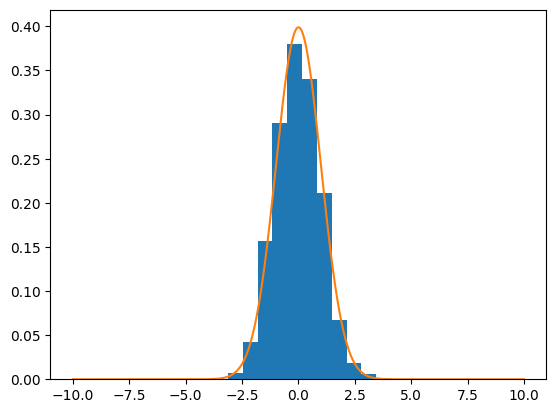

In [10]:
########## Run ##########

# define your model
model = VAE(rnn_enc_hid_dim=256, enc_nconv=1, encoder_hid=256, z_dim=128,
            rnn_dec_hid_dim=512, dec_nconv=3, nchar=len(aa_charset),
            aa_seq_len=max_len)

# compare your sampling with N(0,1)
sample = model.reparametrize(torch.zeros(1000), torch.ones(1000))
plt.hist(sample.detach().cpu().numpy(), density=True)

# plot between -10 and 10 with .001 steps
x_axis = np.arange(-10, 10, 0.001)
plt.plot(x_axis, norm.pdf(x_axis,0,1))  # mean = 0, std = 1
plt.show()

########## Run ##########

### 1.3 <font color="blue">(10 points)</font> Implement the VAE loss function

The decoder model $P_{\theta}(x|z)$, parameterized by a set of parameters $\theta$, takes the sampled latent variable $z \sim Q_{\phi}(z|x) $ to reconstruct $x$ which is your input FASTA sequence. The training objective of a VAE is to minimize the negative evidence lower bound, or ELBO, which can be understood as optimizing a reconstruction loss and regularization term. The regularization term is the KL divergence between the parameterized distribution and the prior distribution.
$$ L = L_{recon} + \beta L_{regularization} = \int dz \:  Q_{\phi}(z|x) \log P_{\theta}(x|z) + \beta \int dz \:  p(z) \log \frac{p(z)}{Q_{\phi}(z|x)} $$

$\beta$ is a hyperparameter that balances the two loss terms (see <a href="#higgins2016beta">Higgins et al. (2016)</a> for more information about the effect of $\beta$). The reconstruction term compares the original input and the decoded inputs. The input data here is a sequence of vectors with encoded categorical values and the output is a sequence with probabilities for each character categories, so we can use <a href="https://pytorch.org/docs/stable/generated/torch.nn.functional.cross_entropy.html">`nn.functional.cross_entropy()`</a> as the training objective to minimize.
$$ L_{recon} = -\frac{1}{N_{seq} N_{char}}\sum_i^{N_{seq}} \sum_k^{N_{char}} p_{data}(\hat{x}_{i, k}) \log(p(x_{i, k})) $$

$\log(p(x_{i, k}))$ is the logit for each possible character category reconstructed by the decoder, $\hat{x}_{i, k}$ is the original protein FASTA, $N_{seq}$ is the length of the sequence, and $N_{char}$ is the total number of possible characters in the sequence. The <a href="https://pytorch.org/docs/stable/generated/torch.nn.functional.cross_entropy.html">`nn.functional.cross_entropy()`</a> method takes two inputs, the predicted logits for each character at each position in the FASTA sequence (dimension = $N_{batch} \times N_{char} \times N_{seq}$), and the original data as character category represented by integers at each position in the padded FASTA sequence (dimension = $N_{batch} \times N_{seq}$).

A simple prior distribution one can choose is a multivariate Gaussian distributions with all the means as zeros, and all the standard deviations as ones. The parameterized distribution from the encoder is a distribution of the same dimension with parametrized means/standard deviation. Minimizing the Kullback-Leibler (KL) divergence between the parametrized distribution $Q_{\phi}(z|x)$ and $\mathcal{N}(0,1)$ encourages the $Q_{\phi}(z|x)$ to be statistically closer to the Gaussian distribution prior $p(z) = \mathcal{N}(0, 1)$. The KL divergence between the encoded latent distribution (approximated posterior) and the prior has a nice analytical form for Gaussian distributions with a diagonal covariance matrix:
$$ L_{regularization} = KL(Q_{\phi}(z|x) | p(z)) = \frac{1}{N_{batch}}\sum_i^{N_{batch}} \frac{1}{2} \left(\sum_d^{N_z} \sigma_{d, \phi}(x_i)^2 + \mu_{d, \phi}(x_i)^2  - \log\sigma_{d, \phi} (x_i)^2 - 1\right) $$
where $d \in \{ 1, ..., N_z \}$ is the index for the latent dimension.

**Task**: For this problem, you need to implement the reconstruction loss and the KL divergence in `loss_function()`. Check your dimensions carefully in this step. In particular, the FASTA input and the decoder output shapes will need the batch size as the first dimension while the second dimension of the decoder output needs to be the number of characters with the last dimensions of both being the sequence length. See the documentation of <a href="https://pytorch.org/docs/stable/generated/torch.nn.functional.cross_entropy.html">`nn.functional.cross_entropy()`</a> for help. Modify your tensor with `transpose()` if necessary to get this to line up.

In [11]:
def loss_function(recon_x, x, mu, std):
    ########## Code ##########

    BCE = F.cross_entropy(recon_x.transpose(1, 2), x, reduction='mean')
    KLD = torch.mean(0.5 * torch.sum(std**2 + mu**2 - torch.log(std**2) - 1, dim=1))

    ########## Code ##########
    return BCE, KLD

### 1.4 <font color="blue">(10 points)</font> Train your model

After implementing the reparameterization trick and loss function, you should be able to train a model with the train and test loop we provided to you. We recommend you save the trained model periodically in your Google Drive with the provided code.

**Task:** Run the provided code chunks to train the VAE for 50 epochs. Make sure you obtain a training and test loss below about 1.6 before proceeding to the next part. Choose `beta=0.001`. This will take around 35 minutes when run on the T4 GPU in Colab.

In [12]:
########## Run ##########

def loop(model, loader, epoch, beta=0.05, evaluation=False):
    """ Train/test your VAE model
    """
    if evaluation:
        model.eval()
        mode = "eval"
    else:
        model.train()
        mode = "train"
    batch_losses = []

    tqdm_data = tqdm(loader, position=0, leave=True, desc=f"{mode} (epoch #{epoch})")
    for data in tqdm_data:
        x = data[0].to(device)
        recon_batch, mu, std = model(x)
        loss_recon, loss_kl = loss_function(recon_batch, x, mu, std)
        loss = loss_recon + beta * loss_kl

        if not evaluation:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        batch_losses.append(loss.item())
        postfix = [f"recon loss={loss_recon.item():.3f}",
                   f"KL loss={loss_kl.item():.3f}",
                   f"total loss={loss.item():.3f}",
                   f"avg. loss={np.array(batch_losses).mean():.3f}"]

        tqdm_data.set_postfix_str(" ".join(postfix))

    return np.array(batch_losses).mean()

########## Run ##########

In [13]:
########## Run ##########

device = "cuda:0"
model = VAE(rnn_enc_hid_dim=256, enc_nconv=1, encoder_hid=256, z_dim=128,
            rnn_dec_hid_dim=512, dec_nconv=3, nchar=len(aa_charset),
            aa_seq_len=max_len)
model = model.to(device)

########## Run ##########

In [14]:
########## Run ##########

optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, "min", factor=0.5, patience=5)

########## Run ##########

Mount your Google Drive to save your model and files (optional).

In [15]:
########## Run (optional) ##########

from google.colab import drive
drive.mount("/content/drive")
mydrive = "/content/drive/MyDrive"

########## Run (optional) ##########

Mounted at /content/drive


In [16]:
########## Run ##########

epochs = 50  # this may take a bit...
for epoch in range(0, epochs):

    train_loss = loop(model, train_loader, epoch, 0.001)
    val_loss = loop(model, val_loader, epoch, 0.001,  evaluation=True)
    scheduler.step(val_loss)

    # uncomment to save model (optional)
    # if epoch % 15 == 0:
    #     torch.save(model.state_dict(), f"{mydrive}/vae-{epoch:03d}-{train_loss:.2f}.pth")
    #     torch.save(optimizer.state_dict(), f"{mydrive}/optim-{epoch:03d}-{train_loss:.2f}.pth")

    if epoch == 0:
        best_loss = train_loss.item()
    else:
        if train_loss.item() < best_loss:
            best_loss = train_loss.item()
    print(best_loss)

########## Run ##########

eval (epoch #0): 100%|██████████| 7/7 [00:02<00:00,  3.44it/s, recon loss=1.839 KL loss=3.628 total loss=1.842 avg. loss=1.866]


2.099413923919201


eval (epoch #1): 100%|██████████| 7/7 [00:02<00:00,  3.01it/s, recon loss=1.782 KL loss=5.735 total loss=1.788 avg. loss=1.784]


1.8936818316578865


eval (epoch #2): 100%|██████████| 7/7 [00:02<00:00,  2.92it/s, recon loss=1.756 KL loss=4.983 total loss=1.761 avg. loss=1.759]


...

0.9857811828454336


eval (epoch #48): 100%|██████████| 7/7 [00:02<00:00,  2.90it/s, recon loss=0.901 KL loss=9.185 total loss=0.910 avg. loss=0.951]


0.9857811828454336


eval (epoch #49): 100%|██████████| 7/7 [00:02<00:00,  2.91it/s, recon loss=0.937 KL loss=9.780 total loss=0.946 avg. loss=0.916]

0.9688209829231104


### 1.5 <font color="orange">(25 points, Grad only)</font> Sample new protein sequences

In [ ]:
########## Run ##########

def index2fasta(mol_index, enc):
    """ Transform your array of character indices back to FASTA
    """
    fasta_charlist = enc.inverse_transform(np.array(mol_index))
    fasta = "".join(fasta_charlist).strip(" ")

    return fasta

########## Run ##########

The latent space learned by the model is a learned continuous space which you can navigate. The space encodes the complicated molecular 'grammar' of the data it trained on. By sampling vectors $z$, you can then use a decoder to reconstruct the continuous representation back to a FASTA protein sequence. Now use your trained model to sample novel protein sequences from the learned distribution.

**Task 1:** Randomly select two protein sequences in your test data, encode into latent vectors with the encoder, and then linearly interpolate between the two protein sequences in the latent space to obtain 10 points in the $z$ space. For each sampled latent code, decode $z$ back to FASTA sequences. You can use the `index2fasta()` function we provided to convert categorical values to FASTA sequences.

In [ ]:
########## Code ##########

# select a starting and ending protein sequence
start = index2fasta(test_loader.dataset.__getitem__(r.choices(range(len(test_loader.dataset)), k=1))[0].numpy().reshape(-1), enc)
end = index2fasta(test_loader.dataset.__getitem__(r.choices(range(len(test_loader.dataset)), k=1))[0].numpy().reshape(-1), enc)
model.eval()

# category representation of FASTA sequence


########## Code ##########

**Task 2:** Produce a scatter plot with the first two dimensions of $z$ of your test sequences and newly sampled sequences in the same figure. Color differently these test points and generated points.

In [ ]:
########## Code ##########


########## Code ##########

*(Task 2 continued)* In a separate table, print the 10 generated FASTA sequences.

In [ ]:
########## Code ##########



########## Code ##########

*(Task 2 continued)* Briefly comment on the sequence diversity you observe among these generated sequences. How many are essentially identical? What do you think can be done to improve the model in its ability to finely interpolate sequences in this learned latent space?

**Write answer here**.



## Part 2: Predicting DNA binding sites with transformers

In this part, you will try using transformers to predict DNA binding sites much like you previously did with LSTM models. If you recall from pset 2, you've been provided a dataset of DNA sequences and a binary label 0/1 that indicates if the sequence binds to a protein or not. The sample data format is summarized again in Table 1.

| DNA sequence | binder or not |
| --- | --- |
| `ATCGGGAA...` | 1 |
| `TGCAGTAT...` | 0 |
| ... | ... |


<div align="center">
  <img src="https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps5-bio/figures/chip.jpeg" width="600px" />
</div>
<div align="center">A typical ChIP workflow (<a href="https://www.creativebiomart.net/epigenetics/services/chromatin-analysis-service/chip-based-service/chip-seq-service/histone-chip-seq/">source</a>)</div>

Just as was needed for the LSTM model in pset 2, you'll want a GPU for this task. Because the data is formatted as strings like "ATGTCA...", we had one-hot encoded the DNA sequences into bit vectors of size 4 (corresponding to the 4 possible DNA bases A, T, G, and C). We'll reuse much of the code from this previous problem, so you don't have to re-implement the dataset configuration or training/testing functions.

In [17]:
########## Run ##########

df = pd.read_csv("./dna_binding.csv")

sequences = df.seq.values
y = df.bind.values

########## Run ##########

In [18]:
########## Run ##########

def SeqEnc(sequences):
    '''
    A function to one-hot encode DNA sequences

    Args:
        sequences (list): list of DNA sequences

    Returns:
        np.array: array with shape (N,C,4) where N is the number of sequences
        and C is the sequence length
    '''

    X = []
    base_dict = {'A': 0, 'C': 1, 'G': 2, 'T': 3}

    for seq in sequences:
        onehot = []
        for base in seq:
            vec = np.zeros(4)
            vec[base_dict[base]] = 1
            onehot.append(vec)
        X.append(np.array(onehot))

    return np.array( X )

X = SeqEnc(sequences)
print("Shape of X is {}.".format(X.shape))

########## Run ##########

Shape of X is (12904, 101, 4).


In [19]:
########## Run ##########

# generate dataset
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.Tensor(np.array(X))  # store X as a pytorch Tensor
        self.y = torch.Tensor(np.array(y))  # store y as a pytorch Tensor
        self.len=len(self.X)                # number of samples in the data

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.len

########## Run ##########

In [20]:
########## Run ##########

X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.1, random_state=42)

# define dataset
train_data = SequenceDataset(X_train, y_train)
val_data = SequenceDataset(X_val, y_val)
test_data = SequenceDataset(X_test, y_test)

# train/test split
batch_size = 256
train_loader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset=val_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_data, batch_size=batch_size, shuffle=True)

########## Run ##########

In [21]:
########## Run ##########

def train(model, dataloader, optimizer, device):

    '''
    A function to train on the entire dataset for one epoch.

    Args:
        model (torch.nn.Module): Your sequence classifier
        dataloader (torch.utils.data.Dataloader): DataLoader object for the train data
        optimizer (torch.optim.Optimizer): Optimizer object to interface gradient calculation and optimization
        device (str): Your device

    Returns:
        float: loss averaged over all the batches

    '''

    epoch_loss = []
    model.train()

    for batch in dataloader:
        seq, label  = batch
        seq = seq.to(device)
        label = label.to(device)

        proba =  model(seq)

        loss = F.binary_cross_entropy(proba.squeeze(),label)
        epoch_loss.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return np.array(epoch_loss).mean()


def validate(model, dataloader, device):

    '''
    A function to validate on the validation dataset for one epoch.

    Args:
        model (torch.nn.Module): Your sequence classifier
        dataloader (torch.utils.data.Dataloader): DataLoader object for the validation data
        device (str): Your device

    Returns:
        float: loss averaged over all the batches

    '''

    val_loss = []
    model.eval()
    with torch.no_grad():
        for batch in dataloader:

            seq, label  = batch
            seq = seq.to(device)
            label = label.to(device)

            proba = model(seq)
            loss = F.binary_cross_entropy(proba.squeeze(),label)

            val_loss.append(loss.item())

        return np.array(val_loss).mean()

def evaluate(model, dataloader, device):

    '''
    A function to return the classification probabilities and true labels (for evaluation).

    Args:
        model (torch.nn.Module): your sequence classifier
        dataloader (torch.utils.data.Dataloader): DataLoader object for the train data
        device (str): Your device

    Returns:
        (np.array, np.array): true labels, predicted probabilities
    '''

    pred_prob = []
    labels = []

    with torch.no_grad():
        model.eval()
        for batch in dataloader:
            epoch_loss = []
            seq, label = batch

            seq = seq.to(device)
            label = label.to(device)

            # Forward pass
            proba = model(seq)
            batch_pred=proba.squeeze().cpu().detach().numpy().tolist()
            batch_labels=label.cpu().numpy().squeeze().tolist()

            labels += batch_labels
            pred_prob += batch_pred

    return labels, pred_prob

########## Run ##########

### 2.1 <font color="blue">(15 points)</font> Implement a transformer encoder for DNA binding

Using a transformer encoder, we will attempt to enrich our one-hot encoded sequence using the information contained within the sequence itself. As described in lecture, we need to provide transformers with positional information on how tokens (in our case As, Ts, Gs, and Cs) are arranged in the sequence. The positional encoding module have already been made for you. We'll first need to make the encoder and then define how we're pooling the encoded sequence for predictions.

Run the following to define our positional encodings.

In [22]:
########## Run ##########

class PositionalEncoding(nn.Module):
    """ Defines positional encoding (adapted from PyTorch's
        documentation)
    """
    def __init__(self, d_model):
        super().__init__()

        position = torch.arange(101).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0)/d_model))
        pe = torch.zeros(1, 101, d_model)
        pe[:, :, 0::2] = torch.sin(position * div_term)
        pe[:, :, 1::2] = torch.cos(position * div_term)

        self.dropout = nn.Dropout(p=0.2)
        self.register_buffer("pe", pe)

    def forward(self, x):
        x += self.pe
        return self.dropout(x)

########## Run ##########

**Task 1:** Define your transformer encoder layers (`self.layer`) in `TransformerSeq()` using <a href="https://pytorch.org/docs/stable/generated/torch.nn.TransformerEncoderLayer.html">`nn.TransformerEncoderLayer()`</a>. Set the keyword arguments for this as follows `d_model=d_model`, `dim_feedforward=128`, `nhead=nhead`, and `batch_first=True`. Next, construct the transformer encoder (`self.encoder`) from your layer using <a href="https://pytorch.org/docs/stable/generated/torch.nn.TransformerEncoder.html">`nn.TransformerEncoder()`</a> with arguments `self.layer` and `num_layers` in the respective order (see the documentation for more information).

**Task 2:** Configure the forward pass of the transformer encoder by passing `x_in` through the encoder you defined above. Because our encoder returns our sequence with the same shape as the input ($N_{\text{batch}} \times  N_{\text{seq}} \times N_{\text{d\_model}}$), we need to pool the encodings across the sequence with `torch.mean(x_out, axis=1)` and output the predictions through a <a href="https://pytorch.org/docs/stable/generated/torch.nn.Linear.html">`nn.Linear()`</a> and <a href="https://pytorch.org/docs/stable/generated/torch.nn.Sigmoid.html">`nn.Sigmoid()`</a>.

In [23]:
class TransformerSeq(nn.Module):
    """ Defines DNA sequence transformer
    """
    def __init__(self, d_model, nhead, num_layers, positional=True):
        super(TransformerSeq, self).__init__()
        self.positional = positional

        # to prep transformer input
        self.in_full = nn.Linear(4, d_model)
        self.pe = PositionalEncoding(d_model)

        ########## Code ##########

        # transformer encoder
        self.layer = nn.TransformerEncoderLayer(d_model=d_model, dim_feedforward=128,
                                                nhead=nhead, batch_first=True)
        self.encoder = nn.TransformerEncoder(self.layer, num_layers=num_layers)

        ########## Code ##########

        # to output probability
        self.out_full = nn.Linear(d_model, 1)
        self.pred = nn.Sigmoid()

    def forward(self, x):
        # apply embedding and positional encoding
        if self.positional:
            x_in = self.pe(self.in_full(x))
        else:
            x_in = self.in_full(x)

        ########## Code ##########

        # apply transformer encoder and pool output
        x_out = self.encoder(x_in)
        pooled = torch.mean(x_out, axis=1)

        # get probability
        pred = self.pred(self.out_full(pooled))

        ########## Code ##########

        return pred

### 2.2 <font color="blue">(15 points)</font> Explore how positional encodings improve classification

Now that you've implemented your transformer, we'd like to explore how  positional encodings are imperative to learning sequence data. If you look at the transformer implementation, we've added the `positional` keyword argument. With this setting, we can turn the positional encoding OFF and ON. You won't need to train the transformer for very many epochs, just enough to see the differences.

**Task 1:** Complete the code to train one `TransformerSeq()` model with positional encodings (`positional=True`) and one without (`positional=False`). For both models, use `d_model=16`, `nhead=8`, and `num_layers=2` and <a href="https://pytorch.org/docs/stable/generated/torch.optim.Adam.html">`torch.optim.Adam()`</a> with `lr=1e-3`. Save the training/validation loss for each model with the provided code. Train the models for `100` epochs.

In [24]:
device = "cuda:0"

########## Code ##########

# model with positional encodings off
model_off = TransformerSeq(d_model=16, nhead=8, num_layers=2, positional=False).to(device)
optimizer_off = torch.optim.Adam(model_off.parameters(), lr=1e-3)


# model with positional encodings on
model_on = TransformerSeq(d_model=16, nhead=8, num_layers=2, positional=True).to(device)
optimizer_on = torch.optim.Adam(model_on.parameters(), lr=1e-3)

########## Code ##########

# hold loss for each model
val_loss_off, val_loss_on = [], []
train_loss_off, train_loss_on = [], []

epochs = 100
for epoch in tqdm(range(epochs), desc="Progress"):

    # compute training/validation loss for off model
    train_loss_off.append(train(model_off, train_loader, optimizer_off, device=device))
    val_loss_off.append(validate(model_off, val_loader, device=device))

    ########## Code ##########

    # compute training/validation loss for on model
    train_loss_on.append(train(model_on, train_loader, optimizer_on, device=device))
    val_loss_on.append(validate(model_on, val_loader, device=device))

    ########## Code ##########

Progress: 100%|██████████| 100/100 [03:11<00:00,  1.92s/it]


**Task 2:** Now visualize the training/validation curves between these two models. Make two subplots side-by-side.

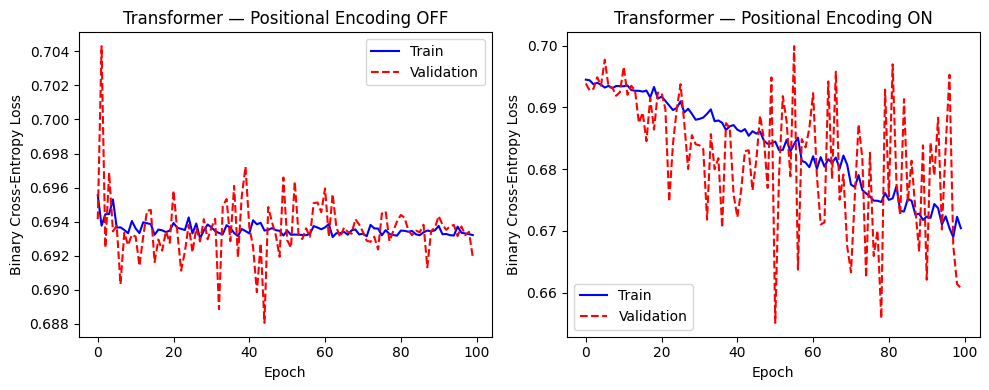

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

########## Code ##########
axes[0].plot(train_loss_off, label='Train', color='blue')
axes[0].plot(val_loss_off, label='Validation', color='red', linestyle='--')
axes[0].set_title('Transformer — Positional Encoding OFF')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Cross-Entropy Loss')
axes[0].legend()

axes[1].plot(train_loss_on, label='Train', color='blue')
axes[1].plot(val_loss_on, label='Validation', color='red', linestyle='--')
axes[1].set_title('Transformer — Positional Encoding ON')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Binary Cross-Entropy Loss')
axes[1].legend()

########## Code ##########

fig.tight_layout()

*(Task 2 continued)* Comment on what you see. From what you know about transformers, why are positional encodings here necessary? If the two plots happened to be identical, what might that tell us?

**The model with positional encoding shows a clear downward trend in both training and validation loss. The graph without positional encoding flatlines almost immediately. DNA binding is a positional problem since the order of the bases have biological meaning. The self-attention mechanim in a transformer is permutation-invariant so without positional encodings, the model sees each sequence as an unordered sequence of bases (permuting the input leaves the output unchanged). If the two plots were identical, that would suggest that the model is not actually usuing positional information to make predictions, meaning position carries no predictive signal for this dataset.**

---

# Submission

Congratulations! You've reached the end of the pset. Please submit your completed work as a `.ipynb` to Gradescope. Furthermore, if you had any AI-based assistance or worked with collaborators, please list them in the following cell.

**For submission:**
If your file is less than 10mb, feel free to turn in the `.ipynb` directly.

However, if it is >10mb, please take a look at the `# --- Configuration ---` section of the next cell. You will need to change the `NOTEBOOK_NAME` to match the name of your google colab notebook. After making the applicable changes, make sure to save your file, and then please run the cell which will reduce the size of your generated images and aim for a file size of less than 10 mb. Note that it will also delete cells tagged as "background". Check the output to ensure it didn't delete any of your outputs.

When successful, you'll be prompted to download the reformatted notebook which you can then upload to gradescope.

In [1]:
import io
import os
import base64
import nbformat
import sys
import time
from PIL import Image
from IPython.display import display, Javascript, HTML

# --- Configuration ---
NOTEBOOK_NAME = "7C01_PSET5.ipynb" # The name of your file
OUTPUT_FILENAME = "pset_5_bio_submission.ipynb"
TAG_TO_REMOVE = "background"
MAX_IMG_WIDTH = 800
# Standard locations where Colab saves notebooks.
# IF YOU CHANGE THE LOCATION OF YOUR NOTEBOOK PLEASE ADD THE PATH HERE.
COLAB_PATHS = [
    f"/content/drive/MyDrive/Colab Notebooks/{NOTEBOOK_NAME}",
    f"/content/drive/MyDrive/{NOTEBOOK_NAME}"
]
# ---------------------

def get_input_path():
    """Determines the path of the notebook based on the environment."""
    if 'google.colab' in sys.modules:
        from google.colab import drive
        # 1. Mount Drive
        if not os.path.exists('/content/drive'):
            print("Mounting Google Drive to access the notebook file...")
            drive.mount('/content/drive')

        for path in COLAB_PATHS:
            if os.path.exists(path):
                return path

        # Fallback if not found
        print(f"\nERROR: Could not find '{NOTEBOOK_NAME}' in your Google Drive.")
        print("Please ensure the file is saved in 'My Drive' or 'Colab Notebooks'.")
        return None

    else:
        # Local Jupyter (runs in current directory)
        return NOTEBOOK_NAME

def resize_base64_image(b64_str, mime_type):
    # (Same resize logic as before - keeping it brief for readability)
    try:
        img_data = base64.b64decode(b64_str)
        img = Image.open(io.BytesIO(img_data))
        if img.width > MAX_IMG_WIDTH:
            ratio = MAX_IMG_WIDTH / img.width
            new_height = int(img.height * ratio)
            img = img.resize((MAX_IMG_WIDTH, new_height), Image.Resampling.LANCZOS)
            buf = io.BytesIO()
            fmt = 'PNG' if 'png' in mime_type else 'JPEG'
            img.save(buf, format=fmt, optimize=True)
            return base64.b64encode(buf.getvalue()).decode('utf-8')
        return b64_str
    except Exception as e:
        return b64_str

def generate_submission():
    # Trigger a save in the browser
    display(Javascript('IPython.notebook.save_checkpoint();'))
    time.sleep(5)

    input_path = get_input_path()
    if not input_path:
        return

    print(f"Reading notebook from: {input_path}")

    try:
        with open(input_path, 'r', encoding='utf-8') as f:
            nb = nbformat.read(f, as_version=4)
    except Exception as e:
        print(f"Error reading file: {e}")
        return

    new_cells = []

    # Filter Cells & Process Images
    for cell in nb.cells:
        tags = cell.get('metadata', {}).get('tags', [])
        tags = [t.lower() for t in tags] if tags else []
        if TAG_TO_REMOVE in tags:
            continue

        if 'outputs' in cell:
            for output in cell['outputs']:
                data = output.get('data', {})
                for mime_type in ['image/png', 'image/jpeg']:
                    if mime_type in data:
                        data[mime_type] = resize_base64_image(data[mime_type], mime_type)
        new_cells.append(cell)

    nb.cells = new_cells

    with open(OUTPUT_FILENAME, 'w', encoding='utf-8') as f:
        nbformat.write(nb, f)

    # Download logic for Colab
    if 'google.colab' in sys.modules:
        from google.colab import files
        print(f"Downloading {OUTPUT_FILENAME}...")
        files.download(OUTPUT_FILENAME)
        print(f"Success! {OUTPUT_FILENAME} downloaded.")
    else:
        print(f"Success! {OUTPUT_FILENAME} created.")
        display(HTML(f'<br/><a href="{OUTPUT_FILENAME}" download><b>Click here to download {OUTPUT_FILENAME}</b></a>'))

generate_submission()

<IPython.core.display.Javascript object>

Mounting Google Drive to access the notebook file...
Mounted at /content/drive
Reading notebook from: /content/drive/MyDrive/Colab Notebooks/7C01_PSET5.ipynb


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Success! pset_5_bio_submission.ipynb downloaded.
